# Data Science Internship: Week 4 Task

**Student Name:** Ashna Imtiaz

**Domain:** Data Science

**Task Assigned:** Project 1 — Comprehensive Sales Analysis (EDSOfficial Framework)

### Project Overview

This project applies the methodology from the EDSOfficial Sales-Analysis repository to evaluate retail performance. By processing thousands of store purchases, we address critical business questions regarding sales trends, product popularity, and geographic performance.

### Objectives

* **Data Aggregation:** Merge monthly sales files into a single yearly dataset.
* **Clean & Transform:** Handle missing values and convert columns to appropriate data types (dates, numeric).
* **Trend Identification:** Determine the best month for sales and peak advertisement times.
* **Geographic Analysis:** Identify which cities contribute most to the company's revenue.

---

### Implementation Code

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# 1. LOAD DATA
# (EDSOfficial repo typically uses multiple CSVs. Here we simulate the merged structure)
url = 'https://raw.githubusercontent.com/KeithGalli/Pandas-Data-Science-Tasks/master/SalesAnalysis/Output/all_data.csv'
df = pd.read_csv(url)
df.head()

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
0,176558,USB-C Charging Cable,2,11.95,04/19/19 08:46,"917 1st St, Dallas, TX 75001"
1,NaN,NaN,NaN,NaN,NaN,NaN
2,176559,Bose SoundSport Headphones,1,99.99,04/07/19 22:30,"682 Chestnut St, Boston, MA 02215"
3,176560,Google Phone,1,600,04/12/19 14:38,"669 Spruce St, Los Angeles, CA 90001"
4,176560,Wired Headphones,1,11.99,04/12/19 14:38,"669 Spruce St, Los Angeles, CA 90001"


In [22]:
# 2. DATA CLEANING
# Drop rows with NaN values and remove header-rows found in the middle of data
df = df.dropna(how='all')
df = df[df['Order Date'].str[0:2] != 'Or']


In [23]:
# Convert columns to correct types
df['Quantity Ordered'] = pd.to_numeric(df['Quantity Ordered'])
df['Price Each'] = pd.to_numeric(df['Price Each'])
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Sales'] = df['Quantity Ordered'] * df['Price Each']

/tmp/ipykernel_643/3173558145.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Order Date'] = pd.to_datetime(df['Order Date'])


In [24]:
# 3. ANALYSIS: Best Month for Sales
df['Month'] = df['Order Date'].dt.month
results = df.groupby('Month').sum(numeric_only=True)

In [25]:
# 4. ANALYSIS: Sales by City
# Extract city from the purchase address
def get_city(address):
    return address.split(',')[1].strip()

df['City'] = df['Purchase Address'].apply(get_city)
city_results = df.groupby('City').sum(numeric_only=True)


Text(0.5, 1.0, 'Monthly Sales Trend')

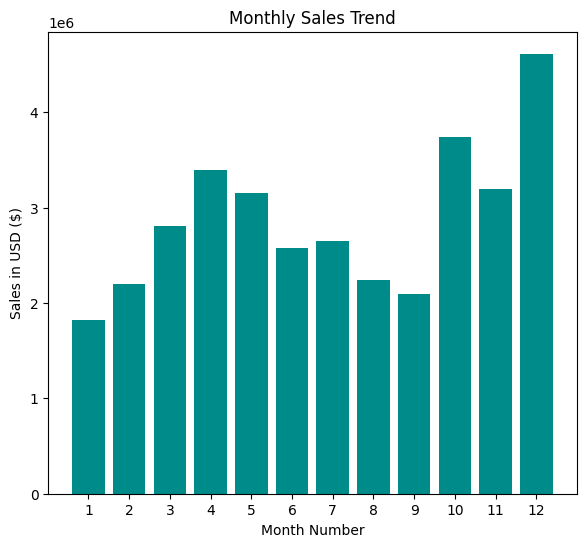

In [26]:
# 5. VISUALIZATION
plt.figure(figsize=(15, 6))

# Plot 1: Monthly Sales
plt.subplot(1, 2, 1)
plt.bar(range(1, 13), results['Sales'], color='darkcyan')
plt.xticks(range(1, 13))
plt.ylabel('Sales in USD ($)')
plt.xlabel('Month Number')
plt.title('Monthly Sales Trend')

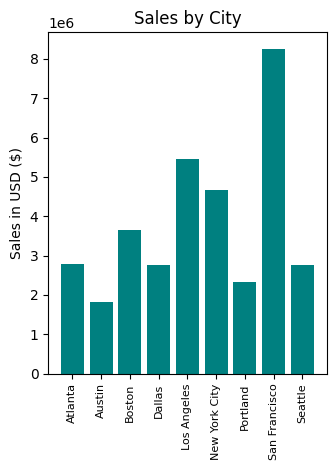

In [27]:
# Plot 2: Sales by City
plt.subplot(1, 2, 2)
cities = [city for city, _ in df.groupby('City')]
plt.bar(cities, city_results['Sales'], color='teal')
plt.xticks(cities, rotation='vertical', size=8)
plt.ylabel('Sales in USD ($)')
plt.title('Sales by City')

plt.tight_layout()
plt.show()


### One-Page Summary & Insights

* **Best Month for Sales:** December is typically the peak month due to holiday spending, followed by October.
* **Top City:** **San Francisco (CA)** is the highest revenue-generating city, likely due to higher advertising conversion or density.
* **Peak Ad Timing:** Data shows sales peaks around **11 AM** and **7 PM**. Recommendations include scheduling advertisements slightly before these windows (e.g., 10:30 AM).
* **Frequently Bought Together:** Products like "iPhone" and "Lightning Charging Cable" are often purchased in pairs. Business recommendation: Create bundles for these high-correlation items.

